# 06. Results Visualization

03·05에서 누적된 run 메트릭과 Optuna study를 정량 시각화.
모델/데이터셋 간 비교 중심.

내용:
1. 전체 run 메트릭 테이블
2. 데이터셋 × 모델 성능 히트맵
3. 반복 실험 box/strip plot
4. Optuna 튜닝 진행 곡선
5. 하이퍼파라미터 중요도
6. 대시보드형 요약 표

In [3]:
import sys, json, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

_HERE = Path.cwd()
if str(_HERE) not in sys.path:
    sys.path.insert(0, str(_HERE))
from utils import nb_utils as U

plt.rcParams.update({'figure.figsize': (10, 5), 'font.size': 11})

## 1. 전체 run 메트릭 테이블

In [4]:
# 특정 데이터셋만 보려면 dataset_id를 지정, 전체는 None
DATASET_ID = None  # or 'AmazonElectronics_x1'

runs = U.list_runs(DATASET_ID)
# 튜닝 trial(tune_t*)을 제외한 최종 run만 필터
final_runs = runs[~runs['run_id'].str.contains('tune_t', na=False)].copy()
print(f'전체 runs: {len(runs)},  최종 runs: {len(final_runs)}')

metric_cols = [c for c in final_runs.columns if c.startswith('metric.')]
display_cols = ['dataset', 'model', 'run_id'] + metric_cols
final_runs[[c for c in display_cols if c in final_runs.columns]].head(30)

전체 runs: 7,  최종 runs: 2


,dataset,model,run_id,metric.train_seconds,metric.valid_AUC,metric.valid_logloss,metric.test_AUC,metric.test_logloss
0,AmazonElectronics_x1,DIN,20260416-121524_DIN_AmazonElectronics_x1_s2026,73.11,0.864903,0.460568,0.852022,0.482683
1,AmazonElectronics_x1,DIN,20260416-121659_DIN_AmazonElectronics_x1_s2027,97.06,0.862924,0.463801,0.845535,0.520752


## 2. 데이터셋 × 모델 AUC 히트맵

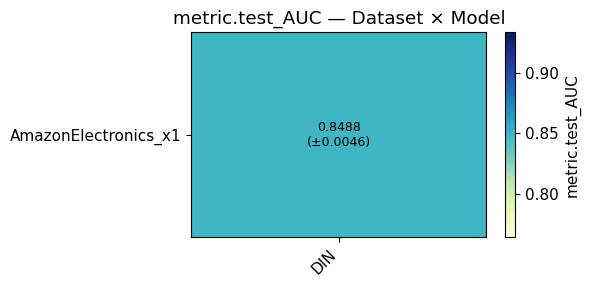

In [5]:
auc_col = 'metric.test_AUC' if 'metric.test_AUC' in final_runs.columns else 'metric.valid_AUC'

if auc_col in final_runs.columns and len(final_runs) > 0:
    pivot = final_runs.groupby(['dataset', 'model'])[auc_col].agg(['mean', 'std']).reset_index()
    pivot_mean = pivot.pivot(index='dataset', columns='model', values='mean')
    pivot_std = pivot.pivot(index='dataset', columns='model', values='std').fillna(0)

    fig, ax = plt.subplots(figsize=(max(6, len(pivot_mean.columns)*2), max(3, len(pivot_mean)*1.5)))
    im = ax.imshow(pivot_mean.values, cmap='YlGnBu', aspect='auto')

    for i in range(pivot_mean.shape[0]):
        for j in range(pivot_mean.shape[1]):
            val = pivot_mean.values[i, j]
            std = pivot_std.values[i, j]
            if not np.isnan(val):
                text = f'{val:.4f}'
                if std > 0:
                    text += f'\n(±{std:.4f})'
                ax.text(j, i, text, ha='center', va='center', fontsize=9)

    ax.set_xticks(range(len(pivot_mean.columns)))
    ax.set_yticks(range(len(pivot_mean.index)))
    ax.set_xticklabels(pivot_mean.columns, rotation=45, ha='right')
    ax.set_yticklabels(pivot_mean.index)
    plt.colorbar(im, ax=ax, label=auc_col)
    ax.set_title(f'{auc_col} — Dataset × Model')
    plt.tight_layout()
    plt.show()
else:
    print(f'{auc_col} not available')

## 3. 반복 실험 box/strip plot

/tmp/ipykernel_2263935/3453613039.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data_auc, labels=models, patch_artist=True)
/tmp/ipykernel_2263935/3453613039.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1].boxplot(data_ll, labels=models, patch_artist=True)


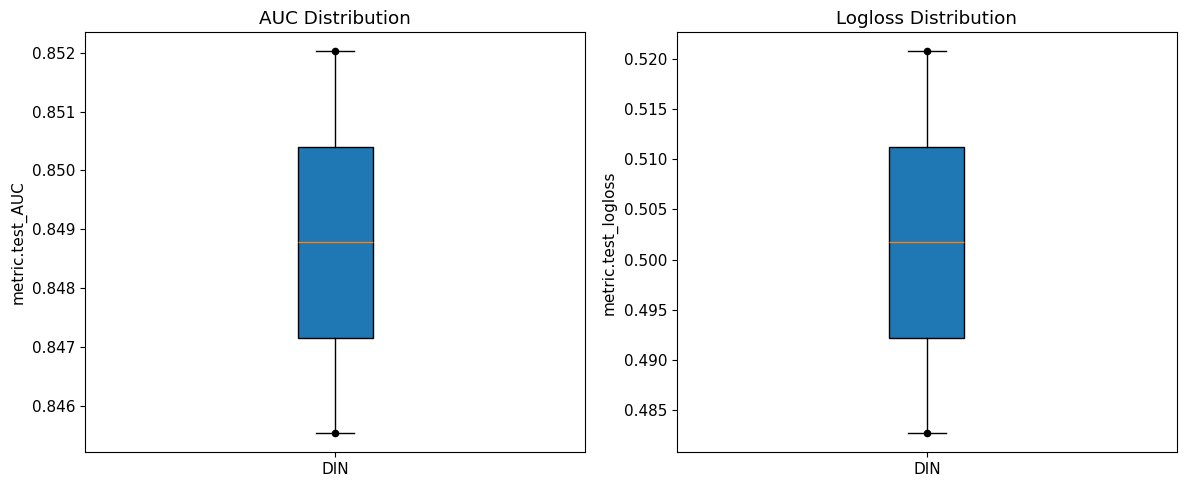

In [6]:
if auc_col in final_runs.columns and len(final_runs) > 1:
    models = final_runs['model'].unique()
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # AUC
    data_auc = [final_runs[final_runs['model'] == m][auc_col].dropna().values for m in models]
    bp = axes[0].boxplot(data_auc, labels=models, patch_artist=True)
    for i, d in enumerate(data_auc):
        axes[0].scatter([i+1]*len(d), d, color='black', s=20, zorder=3)
    axes[0].set_ylabel(auc_col)
    axes[0].set_title('AUC Distribution')

    # Logloss
    ll_col = auc_col.replace('AUC', 'logloss')
    if ll_col in final_runs.columns:
        data_ll = [final_runs[final_runs['model'] == m][ll_col].dropna().values for m in models]
        bp2 = axes[1].boxplot(data_ll, labels=models, patch_artist=True)
        for i, d in enumerate(data_ll):
            axes[1].scatter([i+1]*len(d), d, color='black', s=20, zorder=3)
        axes[1].set_ylabel(ll_col)
        axes[1].set_title('Logloss Distribution')
    else:
        axes[1].set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print('Not enough runs for boxplot')

## 4. Optuna 튜닝 진행 곡선

Found 1 study DBs


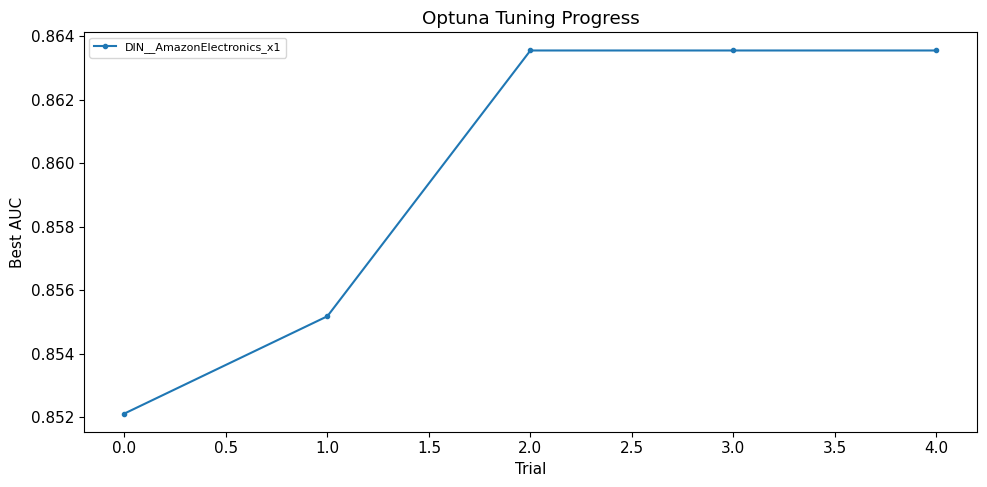

In [7]:
import optuna

tuning_root = U.ARTIFACT_ROOT / 'tuning'
study_dbs = list(tuning_root.rglob('study.db'))
print(f'Found {len(study_dbs)} study DBs')

fig, ax = plt.subplots()
for db_path in study_dbs:
    storage = f'sqlite:///{db_path}'
    summaries = optuna.study.get_all_study_summaries(storage=storage)
    for s in summaries:
        study = optuna.load_study(study_name=s.study_name, storage=storage)
        trials = study.trials
        if not trials:
            continue
        values = []
        best_so_far = -float('inf')
        for t in sorted(trials, key=lambda x: x.number):
            if t.state == optuna.trial.TrialState.COMPLETE and t.value is not None:
                best_so_far = max(best_so_far, t.value)
            values.append(best_so_far if best_so_far > -float('inf') else None)
        valid_vals = [(i, v) for i, v in enumerate(values) if v is not None]
        if valid_vals:
            xs, ys = zip(*valid_vals)
            ax.plot(xs, ys, marker='.', label=s.study_name)

ax.set_xlabel('Trial')
ax.set_ylabel('Best AUC')
ax.set_title('Optuna Tuning Progress')
if study_dbs:
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 5. 하이퍼파라미터 중요도


=== DIN__AmazonElectronics_x1 ===
  learning_rate: 0.3626
  batch_size: 0.2138
  embedding_dim: 0.1724
  net_dropout: 0.0927
  attention_dropout: 0.0819
  dnn_hidden_units: 0.0766


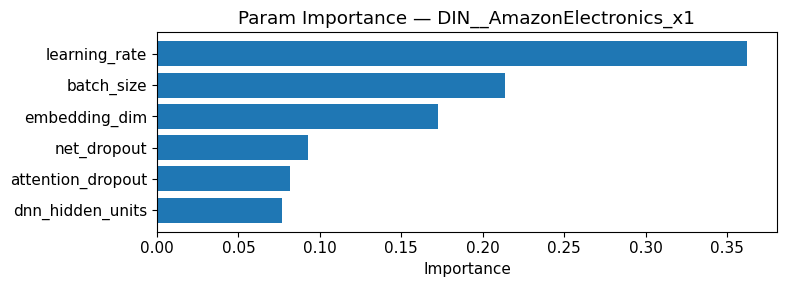

In [8]:
for db_path in study_dbs:
    storage = f'sqlite:///{db_path}'
    summaries = optuna.study.get_all_study_summaries(storage=storage)
    for s in summaries:
        study = optuna.load_study(study_name=s.study_name, storage=storage)
        completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
        if len(completed) < 3:
            print(f'{s.study_name}: only {len(completed)} completed trials — skip importance')
            continue
        try:
            importance = optuna.importance.get_param_importances(study)
            print(f'\n=== {s.study_name} ===')
            for k, v in importance.items():
                print(f'  {k}: {v:.4f}')

            fig, ax = plt.subplots(figsize=(8, max(3, len(importance)*0.5)))
            names = list(importance.keys())
            vals = list(importance.values())
            ax.barh(names[::-1], vals[::-1])
            ax.set_xlabel('Importance')
            ax.set_title(f'Param Importance — {s.study_name}')
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f'{s.study_name}: importance failed ({e!r})')

## 6. 대시보드형 요약 표

In [9]:
if len(final_runs) > 0 and auc_col in final_runs.columns:
    summary = (
        final_runs
        .groupby(['dataset', 'model'])
        .agg(
            n_runs=('run_id', 'count'),
            AUC_mean=(auc_col, 'mean'),
            AUC_std=(auc_col, 'std'),
        )
        .reset_index()
        .sort_values('AUC_mean', ascending=False)
    )
    ll_col = auc_col.replace('AUC', 'logloss')
    if ll_col in final_runs.columns:
        ll_agg = final_runs.groupby(['dataset', 'model'])[ll_col].agg(['mean', 'std'])
        ll_agg.columns = ['logloss_mean', 'logloss_std']
        summary = summary.merge(ll_agg, on=['dataset', 'model'], how='left')

    print('=== Best Model per Dataset ===')
    for ds in summary['dataset'].unique():
        best = summary[summary['dataset'] == ds].iloc[0]
        print(f"  {ds}: {best['model']}  AUC={best['AUC_mean']:.4f} (±{best['AUC_std']:.4f})")

    print('\n=== Full Summary ===')
    summary
else:
    print('No final runs available')

=== Best Model per Dataset ===
  AmazonElectronics_x1: DIN  AUC=0.8488 (±0.0046)

=== Full Summary ===


In [10]:
# (선택) 그림 저장
# fig_dir = U.ARTIFACT_ROOT / 'figures'
# fig_dir.mkdir(parents=True, exist_ok=True)
# fig.savefig(fig_dir / 'heatmap.png', dpi=150)
# print(f'saved to {fig_dir}')